# Notebook 5 - Final comparison with cross-validation

Project 1, part i.

Anne Kristin Furu, FYS-STK4155, fall 2026.

## Setup

In [ ]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from common import BLUE, RED, YELLOW, GREY, GREEN, SEED, savefig
from Get_data import make_data, polynomial_features, scale_center, split, runge
from Errors import mse
from OLS import ols_svd
from Ridge import ridge_closed_form
from LASSO import lasso_ista
from helper import hessian_eigs
np.set_printoptions(precision=4, suppress=True)

x, y = make_data(n=100, noise=0.1, seed=SEED)

## Part i: OLS, Ridge and Lasso with cross-validation

We select each method with 5-fold cross-validation on the Runge data. The scaling is fitted inside each fold. OLS is chosen over the polynomial degree; Ridge and Lasso over both the degree and the penalty.

In [ ]:
def cv_own(x, y, method, degree, lam=0.0, k=5, seed=SEED, iters=5000):
    """k-fold CV with our own solvers, scaling fitted inside each fold."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(x))
    folds = np.array_split(idx, k)
    scores = []
    for j in range(k):
        te = folds[j]
        tr = np.concatenate(folds[:j] + folds[j + 1:])
        Xtr = polynomial_features(x[tr], degree)
        Xte = polynomial_features(x[te], degree)
        Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, y[tr], y[te])
        if method == 'ols':
            th = ols_svd(Xtr, ytr)
        elif method == 'ridge':
            th = ridge_closed_form(Xtr, ytr, lam)
        else:
            L = hessian_eigs(Xtr).max()
            th = lasso_ista(Xtr, ytr, lam, 1.0 / L, num_iters=iters, tol=1e-9)
        scores.append(mse(yte, Xte @ th))
    return np.mean(scores)

### OLS over the degree

OLS: best degree 12, CV MSE 0.01907


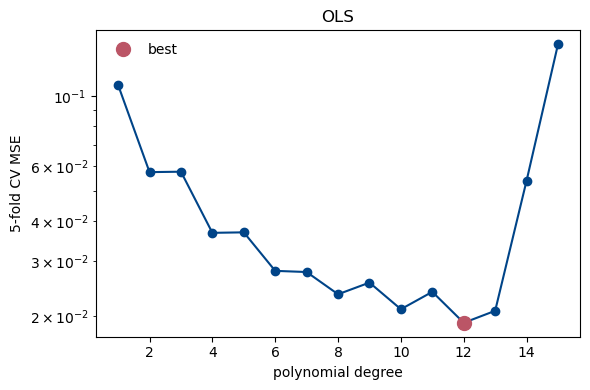

In [ ]:
degrees = list(range(1, 16))
ols_cv = [cv_own(x, y, 'ols', d) for d in degrees]
ols_best_d = degrees[int(np.argmin(ols_cv))]
ols_best = min(ols_cv)
print(f'OLS: best degree {ols_best_d}, CV MSE {ols_best:.5f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(degrees, ols_cv, 'o-', color=BLUE)
ax.plot(ols_best_d, ols_best, 'o', color=RED, ms=10, label='best')
ax.set_yscale('log')
ax.set_xlabel('polynomial degree')
ax.set_ylabel('5-fold CV MSE')
ax.set_title('OLS')
ax.legend(frameon=False)
fig.tight_layout()
savefig('i_ols_cv', fig)
plt.show()

### One-standard-error rule (OLS)

The CV minimum lies in a flat region, so the exact degree is noisy. The one-standard-error rule picks the simplest model whose CV error is within one standard error of the minimum.

In [ ]:
def cv_own_se(x, y, degree, k=5, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(x))
    folds = np.array_split(idx, k)
    scores = []
    for j in range(k):
        te = folds[j]
        tr = np.concatenate(folds[:j] + folds[j + 1:])
        Xtr = polynomial_features(x[tr], degree)
        Xte = polynomial_features(x[te], degree)
        Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, y[tr], y[te])
        th = ols_svd(Xtr, ytr)
        scores.append(mse(yte, Xte @ th))
    scores = np.array(scores)
    return scores.mean(), scores.std() / np.sqrt(k)

ols_mean, ols_se = np.array([cv_own_se(x, y, d) for d in degrees]).T
imin = int(np.argmin(ols_mean))
thr = ols_mean[imin] + ols_se[imin]
onese_d = degrees[[i for i in range(len(ols_mean)) if ols_mean[i] <= thr][0]]
print(f'min at degree {degrees[imin]}: CV MSE {ols_mean[imin]:.4f}, SE {ols_se[imin]:.4f}')
print(f'one-SE rule selects degree {onese_d} (CV MSE {ols_mean[degrees.index(onese_d)]:.4f})')

min at degree 12: CV MSE 0.0191, SE 0.0021
one-SE rule selects degree 10 (CV MSE 0.0211)


In [ ]:
# Seed dependence: new data and new folds for each seed
print(' seed | min degree | CV MSE | SE     | one-SE degree')
levels = []
for s in (SEED, 1, 2, 3, 4, 5):
    xs, ys = make_data(n=100, noise=0.1, seed=s)
    m, se = np.array([cv_own_se(xs, ys, d, seed=s) for d in degrees]).T
    i = int(np.argmin(m)); thr = m[i] + se[i]
    one = min(d for d, v in zip(degrees, m) if v <= thr)
    levels.append(m[i])
    print(f' {s:4d} | {degrees[i]:6d}     | {m[i]:.4f} | {se[i]:.4f} | {one:6d}')
levels = np.array(levels)
print(f'minimum CV MSE over seeds: {levels.mean():.4f} +/- {levels.std():.4f}')

 seed | min degree | CV MSE | SE     | one-SE degree
 2026 |     12     | 0.0191 | 0.0021 |     10
    1 |     10     | 0.0116 | 0.0017 |     10
    2 |     13     | 0.0129 | 0.0012 |     12
    3 |      8     | 0.0142 | 0.0007 |      8
    4 |     12     | 0.0135 | 0.0010 |     10
    5 |     13     | 0.0129 | 0.0018 |     10
minimum CV MSE over seeds: 0.0140 +/- 0.0024


### Ridge over degree and lambda

Ridge: best degree 14, lambda 3.16e-08, CV MSE 0.01846


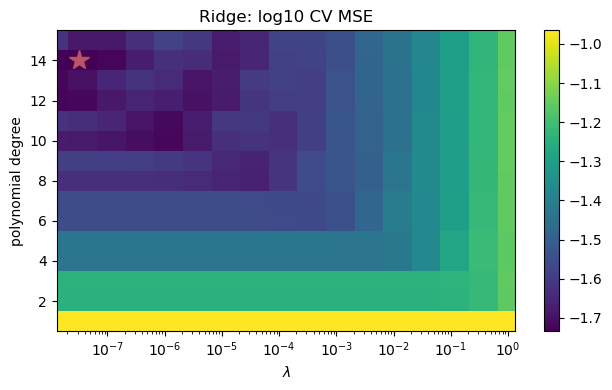

In [ ]:
lams = np.logspace(-8, 0, 17)
ridge_grid = np.array([[cv_own(x, y, 'ridge', d, lam) for lam in lams] for d in degrees])
i0, j0 = np.unravel_index(np.argmin(ridge_grid), ridge_grid.shape)
ridge_best_d, ridge_best_lam, ridge_best = degrees[i0], lams[j0], ridge_grid.min()
print(f'Ridge: best degree {ridge_best_d}, lambda {ridge_best_lam:.2e}, CV MSE {ridge_best:.5f}')

fig, ax = plt.subplots(figsize=(6.5, 4))
im = ax.pcolormesh(lams, degrees, np.log10(ridge_grid), shading='auto', cmap='viridis')
ax.plot(ridge_best_lam, ridge_best_d, '*', color=RED, ms=15)
ax.set_xscale('log')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('polynomial degree')
ax.set_title('Ridge: log10 CV MSE')
fig.colorbar(im, ax=ax)
fig.tight_layout()
savefig('i_ridge_heatmap', fig)
plt.show()

### Lasso over degree and lambda

In [ ]:
lams_l = np.logspace(-4, 0, 10)
deg_l = [4, 6, 8, 10, 12]
lasso_grid = np.array([[cv_own(x, y, 'lasso', d, lam, iters=8000) for lam in lams_l] for d in deg_l])
i1, j1 = np.unravel_index(np.argmin(lasso_grid), lasso_grid.shape)
lasso_best_d, lasso_best_lam, lasso_best = deg_l[i1], lams_l[j1], lasso_grid.min()
print(f'Lasso: best degree {lasso_best_d}, lambda {lasso_best_lam:.2e}, CV MSE {lasso_best:.5f}')

Lasso: best degree 6, lambda 7.74e-04, CV MSE 0.02692


### The three methods side by side

We refit each selected model on all the data and plot it against the true Runge function and the noisy sample.

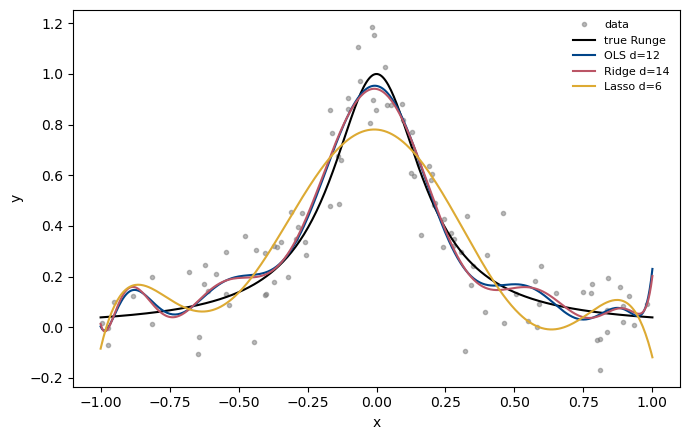

In [ ]:
def fit_predict_full(x, y, method, degree, lam, xnew):
    X = polynomial_features(x, degree)
    xm, xs = X.mean(axis=0), X.std(axis=0)
    xs[xs == 0] = 1.0
    Xs = (X - xm) / xs
    ym = y.mean()
    yc = y - ym
    if method == 'ols':
        th = ols_svd(Xs, yc)
    elif method == 'ridge':
        th = ridge_closed_form(Xs, yc, lam)
    else:
        L = hessian_eigs(Xs).max()
        th = lasso_ista(Xs, yc, lam, 1.0 / L, num_iters=50000, tol=1e-11)
    Xn = (polynomial_features(xnew, degree) - xm) / xs
    return Xn @ th + ym

xg = np.linspace(-1, 1, 400)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x, y, '.', color=GREY, alpha=0.5, label='data')
ax.plot(xg, runge(xg), '-', color='k', lw=1.5, label='true Runge')
ax.plot(xg, fit_predict_full(x, y, 'ols', ols_best_d, 0.0, xg), '-', color=BLUE, label=f'OLS d={ols_best_d}')
ax.plot(xg, fit_predict_full(x, y, 'ridge', ridge_best_d, ridge_best_lam, xg), '-', color=RED, label=f'Ridge d={ridge_best_d}')
ax.plot(xg, fit_predict_full(x, y, 'lasso', lasso_best_d, lasso_best_lam, xg), '-', color=YELLOW, label=f'Lasso d={lasso_best_d}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
savefig('i_fits', fig)
plt.show()

In [ ]:
print('Best cross-validated model per method:')
print(f'  OLS   : degree {ols_best_d}, CV MSE {ols_best:.5f}')
print(f'  Ridge : degree {ridge_best_d}, lambda {ridge_best_lam:.2e}, CV MSE {ridge_best:.5f}')
print(f'  Lasso : degree {lasso_best_d}, lambda {lasso_best_lam:.2e}, CV MSE {lasso_best:.5f}')

Best cross-validated model per method:
  OLS   : degree 12, CV MSE 0.01907
  Ridge : degree 14, lambda 3.16e-08, CV MSE 0.01846
  Lasso : degree 6, lambda 7.74e-04, CV MSE 0.02692


## Summary of part i

The cross-validated errors are close: OLS about 0.019 at degree 12, Ridge about 0.021 at degree 12 with a tiny lambda, and Lasso a little higher at about 0.027 at degree 6. Reading this through the bias-variance decomposition of part c: OLS controls only the degree, so it trades bias against variance by where it stops, and cross-validation keeps it from the worst overfitting of part a. Ridge keeps the high degree but attacks the variance directly, shrinking the small singular-value modes. Lasso attacks the variance too and sets coefficients to zero, lowering the effective complexity, but on this smooth low-dimensional problem with n much larger than p its sparsity buys nothing over OLS, so it lands slightly worse. The evidence supports the reading: the penalties matter most when the model is too flexible for the data, and here, with cross-validation doing the model selection, a well-chosen OLS degree is already hard to beat. Sparsity would pay off with many irrelevant features.